In [1]:
import scanpy as sc
import squidpy as sq
import os

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download a fully processed spatial dataset
adata = sq.datasets.visium_hne_adata()

INFO     Downloading visium_hne_adata.h5ad from                                                                    
         https://exampledata.scverse.org/squidpy/figshare/visium_hne_adata.h5ad                                    


100%|████████████████████████████████████████| 329M/329M [00:00<00:00, 773GB/s]


In [3]:
adata

AnnData object with n_obs × n_vars = 2688 × 18078
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_counts', 'leiden', 'cluster'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cluster_colors', 'hvg', 'leiden', 'leiden_colors', 'neighbors', 'pca', 'rank_genes_groups', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

/tmp/ipykernel_6340/1291410449.py:3: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


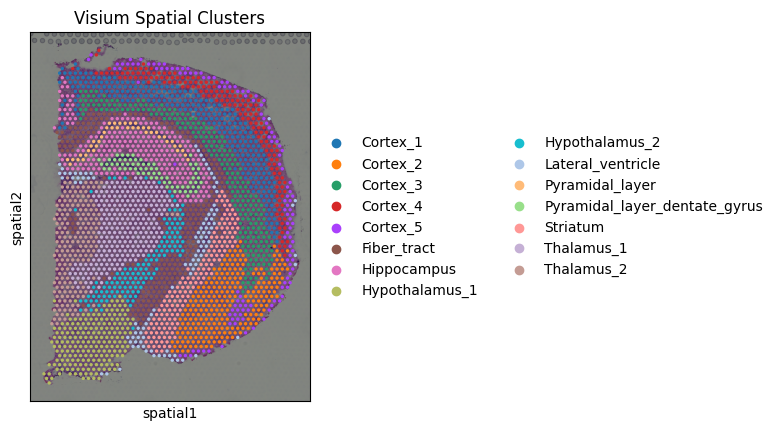

In [4]:
# Plot the spatial data
# Plot 1: Where do the clusters live on the physical tissue?
sc.pl.spatial(
    adata, 
    color="cluster", 
    title="Visium Spatial Clusters"
)

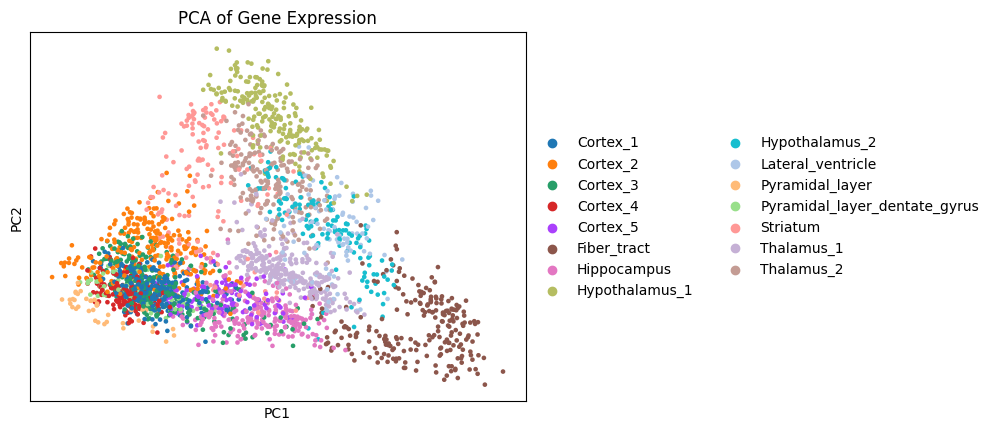

In [5]:
# Plot 2: How biologically distinct are these clusters?
sc.pl.pca(
    adata, 
    color="cluster", 
    title="PCA of Gene Expression"
)

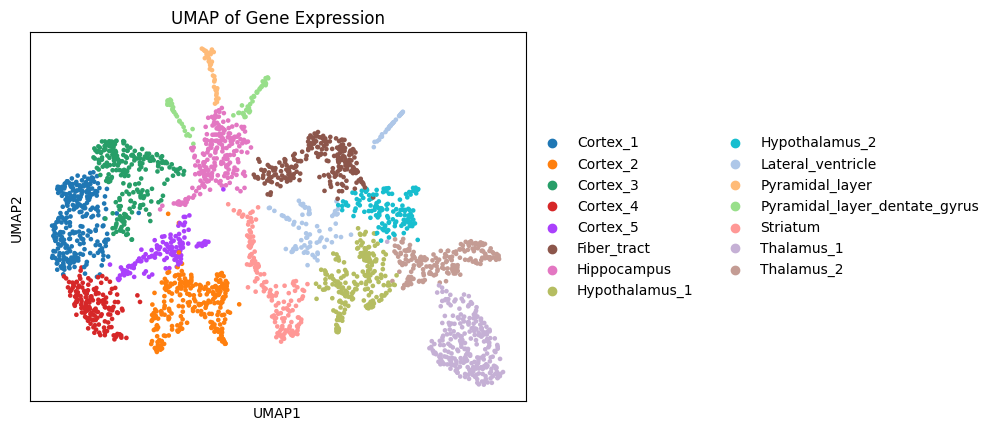

In [6]:
sc.pl.umap(
    adata, 
    color="cluster", 
    title="UMAP of Gene Expression"
)

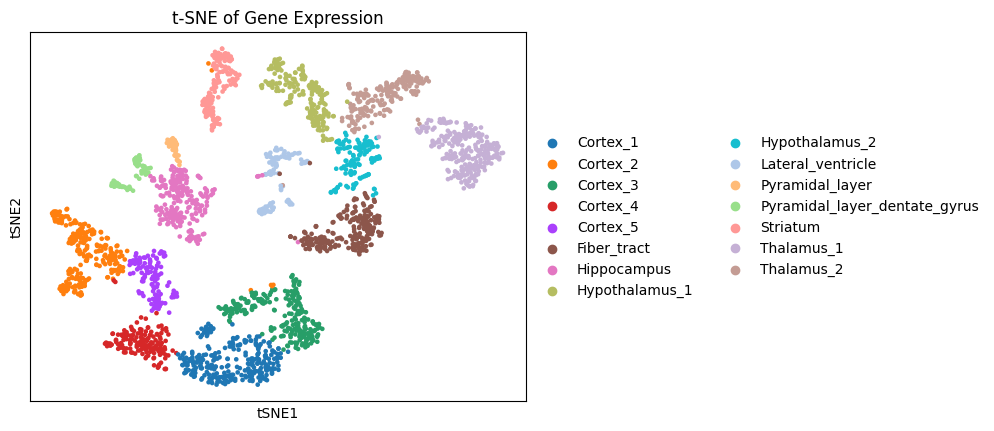

In [7]:
# Let's add t-sne and see if it gives us a different picture
sc.tl.tsne(adata)
sc.pl.tsne(
    adata, 
    color="cluster", 
    title="t-SNE of Gene Expression"
)

/tmp/ipykernel_6340/672699631.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


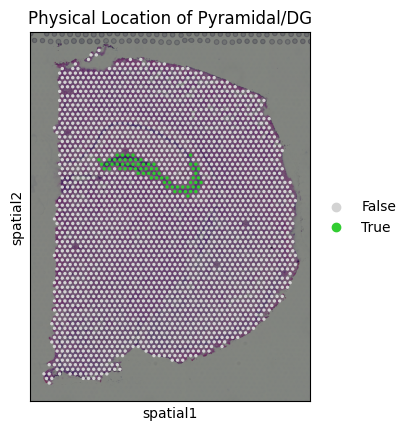

In [8]:
# Create a new column that is True if the spot is Pyramidal/DG, and False otherwise
adata.obs['is_pyramidal'] = (adata.obs['cluster'] == 'Pyramidal_layer_dentate_gyrus').astype(str)

# Plot the tissue, coloring our target cluster bright green and the rest gray
sc.pl.spatial(
    adata, 
    color="is_pyramidal", 
    title="Physical Location of Pyramidal/DG",
    palette={"True": "limegreen", "False": "lightgray"}
)

/tmp/ipykernel_6340/3995371043.py:8: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


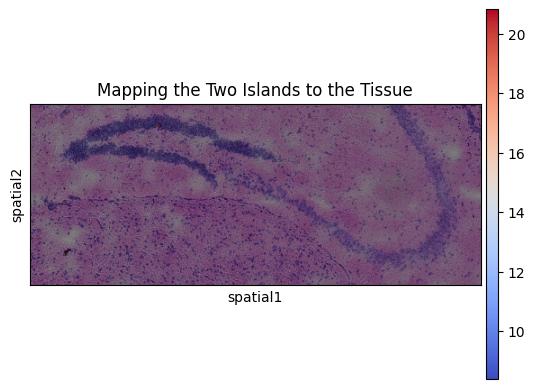

In [9]:
# 1. Isolate just the Pyramidal spots into a mini-dataset
adata_sub = adata[adata.obs['cluster'] == 'Pyramidal_layer_dentate_gyrus'].copy()

# 2. Extract their Y-axis position from the t-SNE plot (which separates the top/bottom islands)
adata_sub.obs['tSNE_split'] = adata_sub.obsm['X_tsne'][:, 1]

# 3. Plot them on the tissue colored by their t-SNE island!
sc.pl.spatial(
    adata_sub, 
    color="tSNE_split", 
    title="Mapping the Two Islands to the Tissue",
    cmap="coolwarm", # Island A will be Red, Island B will be Blue
    spot_size=1.5
)

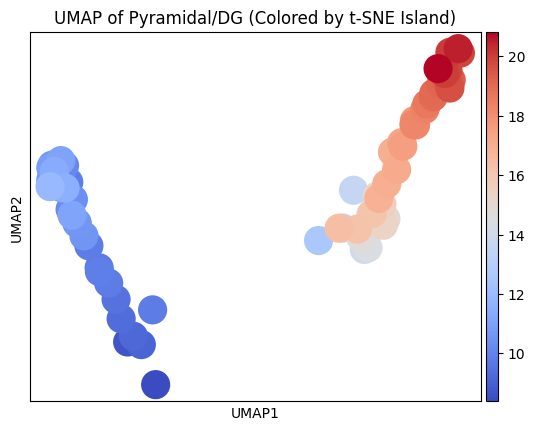

In [10]:
# Plot the UMAP for JUST the Pyramidal/DG cells
# We color them by their position on the t-SNE plot!
sc.pl.umap(
    adata_sub, 
    color="tSNE_split", 
    title="UMAP of Pyramidal/DG (Colored by t-SNE Island)",
    cmap="coolwarm"
)

In [11]:
# Create a clean label for the two islands based on the tSNE split value
# We use 10 as the threshold based on the color bar
adata_sub.obs['sub_cluster'] = ['Island_Red' if val > 10 else 'Island_Blue' for val in adata_sub.obs['tSNE_split']]

# Scanpy requires the grouping variable to be a categorical type
adata_sub.obs['sub_cluster'] = adata_sub.obs['sub_cluster'].astype('category')

In [12]:
# Normalize and log-transform adata
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)                           

# 2. Run the Differential Expression test on ALL clusters
print("Calculating marker genes for ALL clusters...")
sc.tl.rank_genes_groups(adata, groupby='cluster', method='wilcoxon', use_raw=False) # use raw set to False since we already normalized and log-transformed the data

# 3. Automatically loop through every single cluster and print the top 10 genes
top_n_genes = 10
print("Calculating top 10 marker genes for each cluster...")

# This dynamically grabs all the cluster names so you don't have to type them
for cluster_id in adata.obs['cluster'].cat.categories:
    genes = adata.uns['rank_genes_groups']['names'][cluster_id][:top_n_genes]
    print(f"Cluster {cluster_id}: {', '.join(genes)}")

Calculating marker genes for ALL clusters...
Calculating top 10 marker genes for each cluster...
Cluster Cortex_1: Mef2c, Satb1, Nrsn1, Stx1a, 1110008P14Rik, Snap25, Serpini1, Dclk1, Dkkl1, Cabp1
Cluster Cortex_2: Nptxr, Hpcal1, Lmo3, Syn2, Slc30a3, Lypd1, Nov, Cpne6, Olfm1, Gabra2
Cluster Cortex_3: 3110035E14Rik, Tbr1, Ncald, Ttc9b, Pde1a, Hs3st2, Ipcef1, Igsf21, Tmem132a, B3galt2
Cluster Cortex_4: Lamp5, Atp1a1, Rasgrf2, Igfbp6, Mef2c, Cabp1, Itpka, Calb1, Gucy1a1, Cacng3
Cluster Cortex_5: Camk2n1, Camk2a, Slc1a2, Tspan7, mt-Nd5, mt-Atp8, Calm1, Ddn, mt-Nd2, Hpcal4
Cluster Fiber_tract: Mal, Cnp, Cryab, Mobp, Mag, Plp1, Cldn11, Tspan2, Qdpr, Mog
Cluster Hippocampus: Camk2a, Tmsb4x, Mt3, Cox8a, Selenow, Cst3, mt-Nd3, Psd, mt-Nd2, mt-Nd5
Cluster Hypothalamus_1: Resp18, 6330403K07Rik, Gpx3, Ndn, Baiap3, Dlk1, Ahi1, Nrsn2, Rpl22l1, Nap1l5
Cluster Hypothalamus_2: Vamp1, Hcn2, Qdpr, Mobp, Plp1, Sept4, Trf, Gad2, Phlda3, Cnp
Cluster Lateral_ventricle: Fxyd1, Ifitm3, Rbp1, Vim, Id3, Prelp, Db

In [13]:
# Extract the results into a clean DataFrame
# This pulls the gene names, scores, p-values, and log-fold changes for EVERY cluster
marker_genes_df = sc.get.rank_genes_groups_df(adata, group=None)

# Let's look at the first 5 rows just to make sure it worked
print(marker_genes_df.head())

      group          names     scores  logfoldchanges         pvals  \
0  Cortex_1          Mef2c  20.194839        1.159140  1.086809e-90   
1  Cortex_1          Satb1  19.495909        1.769453  1.189237e-84   
2  Cortex_1          Nrsn1  18.561792        0.547282  6.548374e-77   
3  Cortex_1          Stx1a  18.419580        1.355310  9.151028e-76   
4  Cortex_1  1110008P14Rik  18.355064        0.584746  3.007345e-75   

      pvals_adj  
0  1.964733e-86  
1  1.074952e-80  
2  2.367630e-73  
3  2.757205e-72  
4  7.766683e-72  


In [14]:
# Save data
marker_genes_path = "../data/all_marker_genes.csv"
marker_genes_df.to_csv(marker_genes_path, index=False)
print(f"Success! Marker genes saved permanently to: {marker_genes_path}")

save_path = "../data/visium_processed.h5ad"
adata.write(save_path)
print(f"Success! Data saved to: {save_path}")

Success! Marker genes saved permanently to: ../data/all_marker_genes.csv
Success! Data saved to: ../data/visium_processed.h5ad
